# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores.

This is a Python translation of the original R workflow.

## Loading the Data

I selected fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
# Core libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# installed because running on Collab
# !pip install statsmodels lifelines

In [2]:
# Loaded directly from ProPublica GitHub (raw URL, not blob page)
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
len(raw_data)

7214

However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* I coded the recidivist flag -- `is_recid` -- to be -1 if I could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* I filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [3]:
# Select the columns used in the R analysis
df = raw_data[['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex',
               'priors_count', 'days_b_screening_arrest', 'decile_score',
               'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out']].copy()

# Apply the same filters as the R script:
# - screening arrest within 30 days
# - valid recidivism flag (not -1)
# - exclude ordinary traffic offenses
# - exclude missing COMPAS scores
df = df[(df['days_b_screening_arrest'] <= 30) &
        (df['days_b_screening_arrest'] >= -30) &
        (df['is_recid'] != -1) &
        (df['c_charge_degree'] != 'O') &
        (df['score_text'] != 'N/A')].copy()

len(df)  # should be 6172

6172

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [4]:
df['length_of_stay'] = (pd.to_datetime(df['c_jail_out']) - pd.to_datetime(df['c_jail_in'])).dt.days
df['length_of_stay'].corr(df['decile_score'])

np.float64(0.20747808478031807)

After filtering we have the following demographic breakdown:

In [5]:
df['age_cat'].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [6]:
df['race'].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [7]:
race_counts = df['race'].value_counts()
total = len(df)
for race, count in race_counts.items():
    print("%s defendants: %.2f%%" % (race, count / total * 100))

African-American defendants: 51.44%
Caucasian defendants: 34.07%
Hispanic defendants: 8.25%
Other defendants: 5.56%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [8]:
df['score_text'].value_counts()

,count
score_text,
Low,3421
Medium,1607
High,1144


In [9]:
pd.crosstab(df['sex'], df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [10]:
df['sex'].value_counts()

,count
sex,
Male,4997
Female,1175


In [11]:
sex_counts = df['sex'].value_counts()
for sex, count in sex_counts.items():
    print("%s: %.2f%%" % (sex, count / total * 100))

Male: 80.96%
Female: 19.04%


In [12]:
len(df[df['two_year_recid'] == 1])

2809

In [13]:
len(df[df['two_year_recid'] == 1]) / len(df) * 100

45.51198963058976

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

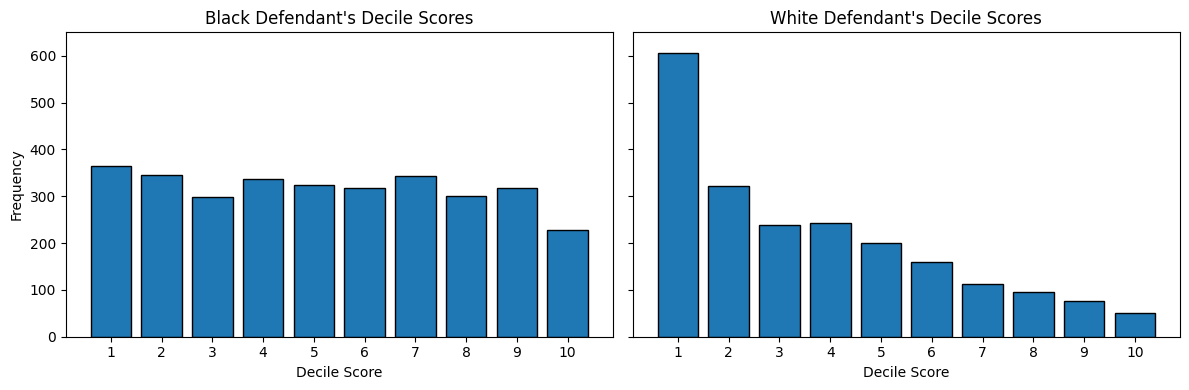

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

df[df['race'] == 'African-American']['decile_score'].plot.hist(
    bins=range(1, 12), align='left', rwidth=0.8, ax=ax1, edgecolor='black')
ax1.set_title("Black Defendant's Decile Scores")
ax1.set_xlabel("Decile Score")
ax1.set_ylim(0, 650)
ax1.set_xticks(range(1, 11))

df[df['race'] == 'Caucasian']['decile_score'].plot.hist(
    bins=range(1, 12), align='left', rwidth=0.8, ax=ax2, edgecolor='black')
ax2.set_title("White Defendant's Decile Scores")
ax2.set_xlabel("Decile Score")
ax2.set_ylim(0, 650)
ax2.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

In [15]:
pd.crosstab(df['decile_score'], df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [16]:
import statsmodels.formula.api as smf

# Create binary target: 1 if Medium or High score, 0 if Low
# This matches the R code: factor(score_text != "Low")
df['score_binary'] = (df['score_text'] != 'Low').astype(int)

# Logistic regression matching the R model specification.
# Reference levels set to match R's relevel():
#   age ref = "25 - 45", race ref = "Caucasian", gender ref = "Male"
# statsmodels Treatment() is equivalent to R's contr.treatment
model = smf.logit(
    'score_binary ~ C(sex, Treatment(reference="Male")) + '
    'C(age_cat, Treatment(reference="25 - 45")) + '
    'C(race, Treatment(reference="Caucasian")) + '
    'priors_count + C(c_charge_degree) + two_year_recid',
    data=df
).fit()

# Note: coefficients may differ slightly from R due to optimizer differences.
# statsmodels uses Newton-Raphson; R's glm uses IRLS. Results are conceptually the same.
model.summary()

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        22:33:09   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
=================================================================================================================================
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------
Intercept                                                        -1.5255      0.079    -19.430      0.000      -1.679      -1.372
C(sex, Treatment(reference="Male"))[T.Female]                     0.2213      0.080      2.783      0.005       0.065       0.377
C(age_cat, Treatment(reference="25 - 45"))[T.Greater than 45]    -1.3556      0.099    -13.682      0.000      -1.550      -1.161
C(age_cat, Treatment(reference="25 - 45"))[T.Less than 25]        1.3084      0.076     17.232      0.000       1.160       1.457
C(race, Treatment(reference="Caucasian"))[T.African-American]     0.4772      0.069      6.881      0.000       0.341       0.613
C(race, Treatment(reference="Caucasian"))[T.Asian]               -0.2544      0.478     -0.532      0.595      -1.192       0.683
C(race, Treatment(reference="Caucasian"))[T.Hispanic]            -0.4284      0.128     -3.344      0.001      -0.680      -0.177
C(race, Treatment(reference="Caucasian"))[T.Native American]      1.3942      0.766      1.820      0.069      -0.107       2.896
C(race, Treatment(reference="Caucasian"))[T.Other]               -0.8263      0.162     -5.098      0.000      -1.144      -0.509
C(c_charge_degree)[T.M]                                          -0.3112      0.067     -4.677      0.000      -0.442      -0.181
priors_count                                                      0.2689      0.011     24.221      0.000       0.247       0.291
two_year_recid                                                    0.6859      0.064     10.713      0.000       0.560       0.811
=================================================================================================================================
"""

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [17]:
# Compute the baseline probability and the percentage change in likelihood
# This replicates the R calculation:
#   control <- exp(intercept) / (1 + exp(intercept))
#   exp(coef) / (1 - control + (control * exp(coef)))
intercept = model.params['Intercept']
control = np.exp(intercept) / (1 + np.exp(intercept))

aa_coef = [v for k, v in model.params.items() if 'African-American' in k][0]
np.exp(aa_coef) / (1 - control + (control * np.exp(aa_coef)))

np.float64(1.452837413382345)

Women are 19.4% more likely than men to get a higher score.

In [18]:
female_coef = [v for k, v in model.params.items() if 'Female' in k][0]
np.exp(female_coef) / (1 - control + (control * np.exp(female_coef)))

np.float64(1.194794653883451)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [19]:
young_coef = [v for k, v in model.params.items() if 'Less than 25' in k][0]
np.exp(young_coef) / (1 - control + (control * np.exp(young_coef)))

np.float64(2.496119530753955)

### Risk of Violent Recidivism

Compas also offers a score that aims to measure a persons risk of violent recidivism, which has a similar overall accuracy to the Recidivism score. As before, we can use a logistic regression to test for racial bias.

In [20]:
violent_url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years-violent.csv"
raw_data_v = pd.read_csv(violent_url)
len(raw_data_v)

4743

In [21]:
vdf = raw_data_v[['age', 'c_charge_degree', 'race', 'age_cat', 'v_score_text', 'sex',
                  'priors_count', 'days_b_screening_arrest', 'v_decile_score',
                  'is_recid', 'two_year_recid']].copy()

vdf = vdf[(vdf['days_b_screening_arrest'] <= 30) &
          (vdf['days_b_screening_arrest'] >= -30) &
          (vdf['is_recid'] != -1) &
          (vdf['c_charge_degree'] != 'O') &
          (vdf['v_score_text'] != 'N/A')].copy()

len(vdf)

4020

In [22]:
vdf['age_cat'].value_counts()

,count
age_cat,
25 - 45,2300
Greater than 45,954
Less than 25,766


In [23]:
vdf['race'].value_counts()

,count
race,
African-American,1918
Caucasian,1459
Hispanic,355
Other,255
Asian,26
Native American,7


In [24]:
vdf['v_score_text'].value_counts()

,count
v_score_text,
Low,2913
Medium,828
High,279


In [25]:
len(vdf[vdf['two_year_recid'] == 1]) / len(vdf) * 100

16.218905472636816

In [26]:
len(vdf[vdf['two_year_recid'] == 1])

652

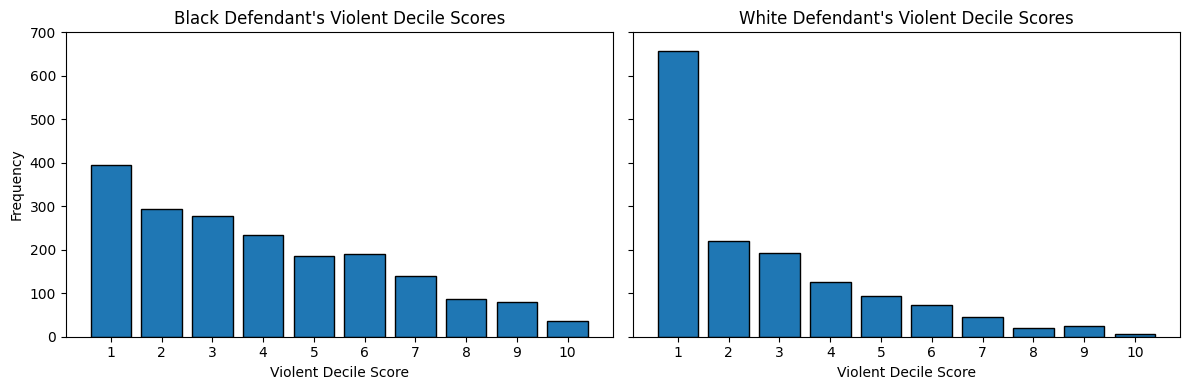

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

vdf[vdf['race'] == 'African-American']['v_decile_score'].plot.hist(
    bins=range(1, 12), align='left', rwidth=0.8, ax=ax1, edgecolor='black')
ax1.set_title("Black Defendant's Violent Decile Scores")
ax1.set_xlabel("Violent Decile Score")
ax1.set_ylim(0, 700)
ax1.set_xticks(range(1, 11))

vdf[vdf['race'] == 'Caucasian']['v_decile_score'].plot.hist(
    bins=range(1, 12), align='left', rwidth=0.8, ax=ax2, edgecolor='black')
ax2.set_title("White Defendant's Violent Decile Scores")
ax2.set_xlabel("Violent Decile Score")
ax2.set_ylim(0, 700)
ax2.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

In [28]:
vdf['v_score_binary'] = (vdf['v_score_text'] != 'Low').astype(int)

vmodel = smf.logit(
    'v_score_binary ~ C(sex, Treatment(reference="Male")) + '
    'C(age_cat, Treatment(reference="25 - 45")) + '
    'C(race, Treatment(reference="Caucasian")) + '
    'priors_count + C(c_charge_degree) + two_year_recid',
    data=vdf
).fit()

vmodel.summary()

Optimization terminated successfully.
         Current function value: 0.372983
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         v_score_binary   No. Observations:                 4020
Model:                          Logit   Df Residuals:                     4008
Method:                           MLE   Df Model:                           11
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.3662
Time:                        22:33:11   Log-Likelihood:                -1499.4
converged:                       True   LL-Null:                       -2365.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
=================================================================================================================================
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------
Intercept                                                        -2.2427      0.113    -19.802      0.000      -2.465      -2.021
C(sex, Treatment(reference="Male"))[T.Female]                    -0.7289      0.127     -5.755      0.000      -0.977      -0.481
C(age_cat, Treatment(reference="25 - 45"))[T.Greater than 45]    -1.7421      0.184     -9.460      0.000      -2.103      -1.381
C(age_cat, Treatment(reference="25 - 45"))[T.Less than 25]        3.1459      0.115     27.259      0.000       2.920       3.372
C(race, Treatment(reference="Caucasian"))[T.African-American]     0.6589      0.108      6.093      0.000       0.447       0.871
C(race, Treatment(reference="Caucasian"))[T.Asian]               -0.9852      0.705     -1.397      0.162      -2.368       0.397
C(race, Treatment(reference="Caucasian"))[T.Hispanic]            -0.0642      0.191     -0.335      0.737      -0.439       0.311
C(race, Treatment(reference="Caucasian"))[T.Native American]      0.4479      1.035      0.433      0.665      -1.582       2.477
C(race, Treatment(reference="Caucasian"))[T.Other]               -0.2054      0.225     -0.914      0.360      -0.646       0.235
C(c_charge_degree)[T.M]                                          -0.1637      0.098     -1.669      0.095      -0.356       0.029
priors_count                                                      0.1376      0.012     11.854      0.000       0.115       0.160
two_year_recid                                                    0.9345      0.115      8.107      0.000       0.709       1.160
=================================================================================================================================
"""

The violent score overpredicts recidivism for black defendants by 77.3% compared to white defendants.

In [29]:
v_intercept = vmodel.params['Intercept']
v_control = np.exp(v_intercept) / (1 + np.exp(v_intercept))
v_aa_coef = [v for k, v in vmodel.params.items() if 'African-American' in k][0]
np.exp(v_aa_coef) / (1 - v_control + (v_control * np.exp(v_aa_coef)))

np.float64(1.7739274140704102)

Defendands under 25 are 7.4 times as likely to get a higher score as middle aged defendants.

In [30]:
v_young_coef = [v for k, v in vmodel.params.items() if 'Less than 25' in k][0]
np.exp(v_young_coef) / (1 - v_control + (v_control * np.exp(v_young_coef)))

np.float64(7.414231992873513)

## Predictive Accuracy of COMPAS

In order to test whether Compas scores do an accurate job of deciding whether an offender is Low, Medium or High risk,  I ran a Cox Proportional Hazards model. Northpointe, the company that created COMPAS and markets it to Law Enforcement, also ran a Cox model in their [validation study](http://cjb.sagepub.com/content/36/1/21.abstract).

I used the counting model and removed people when they were incarcerated. Due to errors in the underlying jail data, we need to filter out 32 rows that have an end date more than the start date. Considering that there are 13,334 total rows in the data, such a small amount of errors will not affect the results.

In [32]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=9ef88a7cf60aaff5ff3ac7777e925a68f43b3b4be4a6903fa48fe0901ba863e4
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [33]:
from lifelines import CoxPHFitter, KaplanMeierFitter

# Load the pre-parsed cox data from ProPublica
cox_url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-parsed.csv"
data = pd.read_csv(cox_url)

# Same filters as R: remove N/A scores and rows where end <= start
data = data[(data['score_text'] != 'N/A') & (data['end'] > data['start'])].copy()
data['duration'] = data['end'] - data['start']

# Encode score as numeric for lifelines (Low=0, Medium=1, High=2)
# R uses factor levels; lifelines needs numeric covariates
score_map = {'Low': 0, 'Medium': 1, 'High': 2}
data['score_num'] = data['score_text'].map(score_map)

# Deduplicate to one row per person for summary stats
grp = data.drop_duplicates(subset='id')
len(grp)

10325

In [34]:
grp['score_text'].value_counts()

,count
score_text,
Low,5751
Medium,2611
High,1952


In [35]:
grp['race'].value_counts()

,count
race,
African-American,5150
Caucasian,3576
Hispanic,944
Other,572
Asian,51
Native American,32


In [36]:
cox_df = data[['duration', 'event', 'score_num']].dropna()
cph = CoxPHFitter()
cph.fit(cox_df, duration_col='duration', event_col='event')
cph.print_summary()
print("\nConcordance: %.3f" % cph.concordance_index_)

<lifelines.CoxPHFitter: fitted with 13344 total observations, 9875 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 13344
number of events observed = 3469
   partial log-likelihood = -31082.15
         time fit was run = 2026-03-29 22:34:39 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
score_num  0.56      1.76      0.02            0.52            0.60                1.69                1.83

           cmp to     z      p  -log2(p)
covariate                               
score_num    0.00 27.64 <0.005    556.10
---
Concordance = 0.62
Partial AIC = 62166.30
log-likelihood ratio test = 726.89 on 1 df
-log2(p) of ll-ratio test = 529.42


Concordance: 0.621


People placed in the High category are 3.5 times as likely to recidivate, and the COMPAS system's concordance 63.6%. This is lower than the accuracy quoted in the Northpoint study of 68%.

In [37]:
cox_decile = data[['duration', 'event', 'decile_score']].dropna()
cph_d = CoxPHFitter()
cph_d.fit(cox_decile, duration_col='duration', event_col='event')
cph_d.print_summary()
print("\nConcordance: %.3f" % cph_d.concordance_index_)

<lifelines.CoxPHFitter: fitted with 13356 total observations, 9885 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 13356
number of events observed = 3471
   partial log-likelihood = -31025.54
         time fit was run = 2026-03-29 22:34:46 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
decile_score  0.17      1.19      0.01            0.16            0.19                1.18                1.20

              cmp to     z      p  -log2(p)
covariate                                  
decile_score    0.00 29.90 <0.005    650.09
---
Concordance = 0.65
Partial AIC = 62053.09
log-likelihood ratio test = 885.36 on 1 df
-log2(p) of ll-ratio test = 643.88


Concordance: 0.646


COMPAS's decile scores are a bit more accurate at 66%.

We can test if the algorithm is behaving differently across races by including a race interaction term in the cox model.

In [38]:
cox_int = data[['duration', 'event', 'score_text', 'race']].dropna().copy()
cox_int['is_black'] = (cox_int['race'] == 'African-American').astype(int)
cox_int['score_high'] = (cox_int['score_text'] == 'High').astype(int)
cox_int['score_med'] = (cox_int['score_text'] == 'Medium').astype(int)
cox_int['black_x_high'] = cox_int['is_black'] * cox_int['score_high']
cox_int['black_x_med'] = cox_int['is_black'] * cox_int['score_med']

cph2 = CoxPHFitter()
cph2.fit(cox_int[['duration', 'event', 'is_black', 'score_high', 'score_med',
                   'black_x_high', 'black_x_med']],
         duration_col='duration', event_col='event')
cph2.print_summary()

<lifelines.CoxPHFitter: fitted with 13344 total observations, 9875 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 13344
number of events observed = 3469
   partial log-likelihood = -31056.21
         time fit was run = 2026-03-29 22:34:49 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
is_black      0.29      1.33      0.06            0.18            0.40                1.20                1.48
score_high    1.19      3.27      0.07            1.05            1.33                2.85                3.76
score_med     0.77      2.16      0.06            0.65            0.89                1.92                2.43
black_x_high -0.22      0.80      0.09           -0.40           -0.05                0.67                0.95
black_x_med  -0.17      0.85      0.08           -0.33           -0.00                0.72                1.00

              cmp to     z      p  -log2(p)
covariate                                  
is_black        0.00  5.20 <0.005     22.22
score_high      0.00 16.61 <0.005    203.36
score_med       0.00 12.63 <0.005    119.00
black_x_high    0.00 -2.50   0.01      6.33
black_x_med     0.00 -1.99   0.05      4.43
---
Concordance = 0.63
Partial AIC = 62122.42
log-likelihood ratio test = 778.77 on 5 df
-log2(p) of ll-ratio test = 549.26

The interaction term shows a similar disparity as the logistic regression above.

High risk white defendants are 3.61 more likely than low risk white defendants, while High risk black defendants are 2.99 more likely than low.

In [39]:
import math
params = cph2.params_
print("Black High Hazard: %.2f" % math.exp(params['black_x_high'] + params['score_high']))
print("White High Hazard: %.2f" % math.exp(params['score_high']))
print("Black Medium Hazard: %.2f" % math.exp(params['score_med'] + params['black_x_med']))
print("White Medium Hazard: %.2f" % math.exp(params['score_med']))

Black High Hazard: 2.62
White High Hazard: 3.27
Black Medium Hazard: 1.83
White Medium Hazard: 2.16


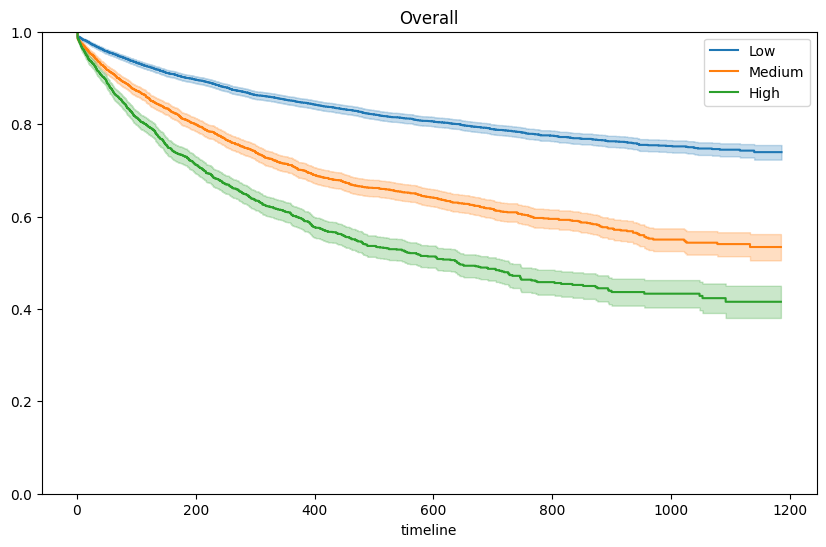

In [40]:
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))
for label in ['Low', 'Medium', 'High']:
    s = data[data['score_text'] == label]
    kmf.fit(s['duration'], event_observed=s['event'], label=label)
    kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_title('Overall')
ax.set_ylim(0, 1)
plt.show()

Black defendants do recidivate at higher rates according to race specific Kaplan Meier plots.

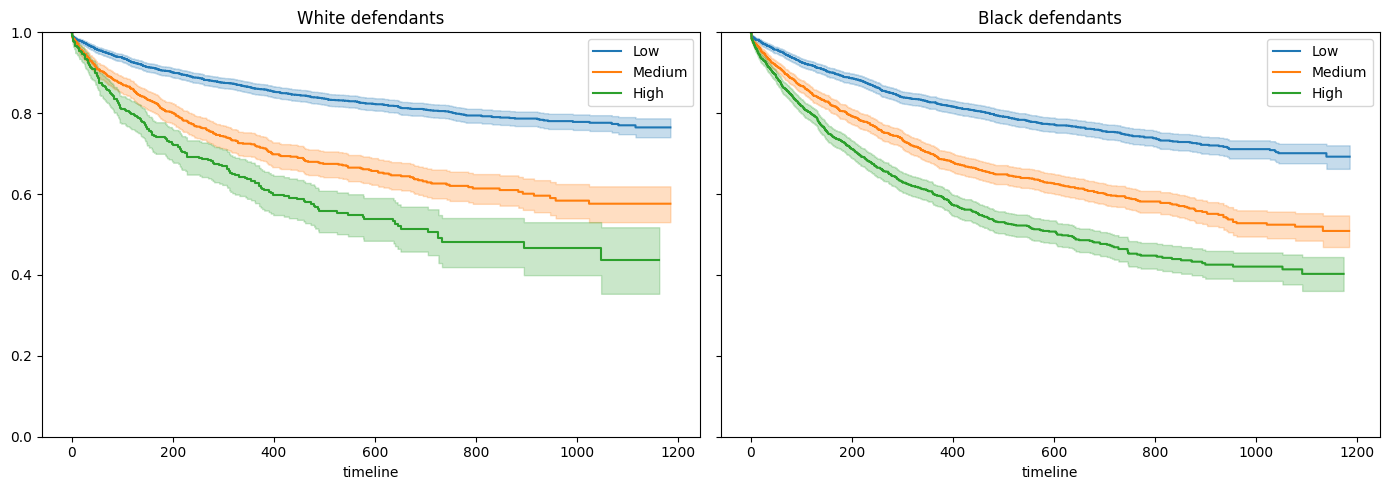

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
kmf = KaplanMeierFitter()
for ax, rname, title in [(ax1, 'Caucasian', 'White defendants'),
                          (ax2, 'African-American', 'Black defendants')]:
    rsub = data[data['race'] == rname]
    for label in ['Low', 'Medium', 'High']:
        s = rsub[rsub['score_text'] == label]
        if len(s) > 0:
            kmf.fit(s['duration'], event_observed=s['event'], label=label)
            kmf.plot_survival_function(ax=ax, ci_show=True)
    ax.set_title(title)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [42]:
for label in ['Low', 'Medium', 'High']:
    s = data[data['score_text'] == label]
    kmf.fit(s['duration'], event_observed=s['event'], label=label)
    print("%s — survival at 730 days: %.3f" % (label, kmf.predict(730)))

Low — survival at 730 days: 0.785
Medium — survival at 730 days: 0.609
High — survival at 730 days: 0.473


In [43]:
print("Black defendants")
for label in ['Low', 'Medium', 'High']:
    s = data[(data['race']=='African-American') & (data['score_text']==label)]
    kmf.fit(s['duration'], event_observed=s['event'], label=label)
    print("%s: %.3f" % (label, kmf.predict(730)))

Black defendants
Low: 0.752
Medium: 0.595
High: 0.464


In [44]:
print("White defendants")
for label in ['Low', 'Medium', 'High']:
    s = data[(data['race']=='Caucasian') & (data['score_text']==label)]
    kmf.fit(s['duration'], event_observed=s['event'], label=label)
    print("%s: %.3f" % (label, kmf.predict(730)))

White defendants
Low: 0.805
Medium: 0.626
High: 0.490


Race specific models have similar concordance values.

In [46]:
white_data = data[data['race']=='Caucasian']
w = white_data[['duration','event','score_num']].dropna()
cph_w = CoxPHFitter()
cph_w.fit(w, duration_col='duration', event_col='event')
cph_w.print_summary()
print("Concordance: %.3f" % cph_w.concordance_index_)

<lifelines.CoxPHFitter: fitted with 4564 total observations, 3541 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 4564
number of events observed = 1023
   partial log-likelihood = -8126.09
         time fit was run = 2026-03-29 22:37:38 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
score_num  0.59      1.81      0.04            0.51            0.67                1.67                1.95

           cmp to     z      p  -log2(p)
covariate                               
score_num    0.00 14.95 <0.005    165.44
---
Concordance = 0.61
Partial AIC = 16254.18
log-likelihood ratio test = 200.75 on 1 df
-log2(p) of ll-ratio test = 148.97

Concordance: 0.612


In [47]:
black_data = data[data['race']=='African-American']
b = black_data[['duration','event','score_num']].dropna()
cph_b = CoxPHFitter()
cph_b.fit(b, duration_col='duration', event_col='event')
cph_b.print_summary()
print("Concordance: %.3f" % cph_b.concordance_index_)

<lifelines.CoxPHFitter: fitted with 6862 total observations, 4827 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 6862
number of events observed = 2035
   partial log-likelihood = -16808.30
         time fit was run = 2026-03-29 22:37:40 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
score_num  0.48      1.62      0.03            0.43            0.53                1.53                1.71

           cmp to     z      p  -log2(p)
covariate                               
score_num    0.00 17.81 <0.005    233.41
---
Concordance = 0.61
Partial AIC = 33618.59
log-likelihood ratio test = 318.12 on 1 df
-log2(p) of ll-ratio test = 233.96

Concordance: 0.608


Compas's violent recidivism score has a slightly higher overall concordance score of 65.1%.

In [48]:
vcox_url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-violent-parsed.csv"
violent_data = pd.read_csv(vcox_url)
violent_data = violent_data[(violent_data['score_text'] != 'N/A') & (violent_data['end'] > violent_data['start'])].copy()
violent_data['duration'] = violent_data['end'] - violent_data['start']
violent_data['score_num'] = violent_data['score_text'].map(score_map)

vgrp = violent_data.drop_duplicates(subset='id')
print(len(vgrp))

vcph = CoxPHFitter()
vcox_df = violent_data[['duration','event','score_num']].dropna()
vcph.fit(vcox_df, duration_col='duration', event_col='event')
vcph.print_summary()
print("\nConcordance: %.3f" % vcph.concordance_index_)

10999


<lifelines.CoxPHFitter: fitted with 18178 total observations, 17360 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 18178
number of events observed = 818
   partial log-likelihood = -7514.51
         time fit was run = 2026-03-29 22:37:43 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
score_num  0.61      1.84      0.04            0.53            0.69                1.70                2.00

           cmp to     z      p  -log2(p)
covariate                               
score_num    0.00 14.60 <0.005    158.03
---
Concordance = 0.64
Partial AIC = 15031.02
log-likelihood ratio test = 207.43 on 1 df
-log2(p) of ll-ratio test = 153.81


Concordance: 0.636


In this case, there isn't a significant coefficient on African American's with High Scores.

In [49]:
vcox_int = violent_data[['duration','event','score_text','race']].dropna().copy()
vcox_int['is_black'] = (vcox_int['race']=='African-American').astype(int)
vcox_int['score_high'] = (vcox_int['score_text']=='High').astype(int)
vcox_int['score_med'] = (vcox_int['score_text']=='Medium').astype(int)
vcox_int['black_x_high'] = vcox_int['is_black'] * vcox_int['score_high']
vcox_int['black_x_med'] = vcox_int['is_black'] * vcox_int['score_med']

vcph2 = CoxPHFitter()
vcph2.fit(vcox_int[['duration','event','is_black','score_high','score_med','black_x_high','black_x_med']],
          duration_col='duration', event_col='event')
vcph2.print_summary()

<lifelines.CoxPHFitter: fitted with 18178 total observations, 17360 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 18178
number of events observed = 818
   partial log-likelihood = -7509.93
         time fit was run = 2026-03-29 22:37:46 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
is_black      0.23      1.26      0.12           -0.01            0.46                0.99                1.59
score_high    1.32      3.73      0.14            1.04            1.59                2.83                4.91
score_med     0.66      1.93      0.13            0.40            0.92                1.49                2.50
black_x_high -0.22      0.80      0.18           -0.58            0.13                0.56                1.14
black_x_med   0.02      1.02      0.18           -0.33            0.37                0.72                1.45

              cmp to     z      p  -log2(p)
covariate                                  
is_black        0.00  1.88   0.06      4.06
score_high      0.00  9.37 <0.005     66.92
score_med       0.00  4.97 <0.005     20.54
black_x_high    0.00 -1.24   0.22      2.22
black_x_med     0.00  0.13   0.90      0.16
---
Concordance = 0.64
Partial AIC = 15029.85
log-likelihood ratio test = 216.60 on 5 df
-log2(p) of ll-ratio test = 146.49

In [50]:
vb = violent_data[violent_data['race']=='African-American'][['duration','event','score_num']].dropna()
vcph_b = CoxPHFitter()
vcph_b.fit(vb, duration_col='duration', event_col='event')
print("Black concordance: %.3f" % vcph_b.concordance_index_)

Black concordance: 0.621


In [51]:
vw = violent_data[violent_data['race']=='Caucasian'][['duration','event','score_num']].dropna()
vcph_w = CoxPHFitter()
vcph_w.fit(vw, duration_col='duration', event_col='event')
print("White concordance: %.3f" % vcph_w.concordance_index_)

White concordance: 0.600


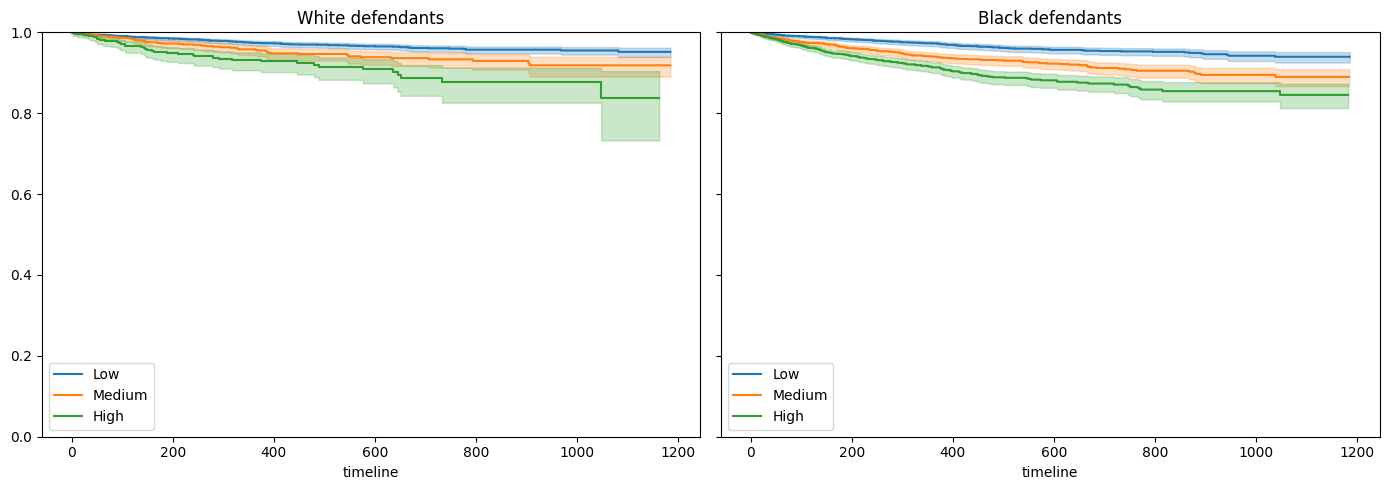

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
kmf = KaplanMeierFitter()
for ax, rname, title in [(ax1, 'Caucasian', 'White defendants'),
                          (ax2, 'African-American', 'Black defendants')]:
    rsub = violent_data[violent_data['race'] == rname]
    for label in ['Low', 'Medium', 'High']:
        s = rsub[rsub['score_text'] == label]
        if len(s) > 0:
            kmf.fit(s['duration'], event_observed=s['event'], label=label)
            kmf.plot_survival_function(ax=ax, ci_show=True)
    ax.set_title(title)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Directions of the Racial Bias

The above analysis shows that the Compas algorithm does overpredict African-American defendant's future recidivism, but we haven't yet explored the direction of the bias. We can discover fine differences in overprediction and underprediction by comparing Compas scores across racial lines.

In [53]:
# The original R notebook uses a custom truth_tables.py module from ProPublica.
# Here we replicate that logic directly using pandas on the cox-parsed data.
# The approach: deduplicate to one row per person, compute lifetime,
# check if they recidivated within 730 days (2 years), then compare
# COMPAS predictions (Medium/High = positive) against actual outcomes.

people_df = pd.read_csv(cox_url)
persons = people_df.drop_duplicates(subset='id').copy()
persons = persons[persons['score_text'].isin(['Low','Medium','High'])].copy()

# get the last observed time and whether they ever had an event
lifetime = people_df.groupby('id')['end'].max().reset_index().rename(columns={'end':'lifetime'})
events = people_df.groupby('id')['event'].max().reset_index().rename(columns={'event':'ever_event'})
persons = persons.merge(lifetime, on='id').merge(events, on='id')

# recidivist = had an event within 2 years
persons['recidivist'] = (persons['ever_event'] == 1) & (persons['lifetime'] <= 730)

# keep people who either recidivated within 2 yrs or were observed for >730 days
pop = persons[(persons['recidivist']) | (persons['lifetime'] > 730)].copy()
pop['predicted_positive'] = pop['score_text'].isin(['Medium','High'])

def truth_table(subset, label):
    """Compute confusion matrix metrics matching ProPublica's truth_tables output."""
    tp = len(subset[(subset['predicted_positive']) & (subset['recidivist'])])
    fp = len(subset[(subset['predicted_positive']) & (~subset['recidivist'])])
    fn = len(subset[(~subset['predicted_positive']) & (subset['recidivist'])])
    tn = len(subset[(~subset['predicted_positive']) & (~subset['recidivist'])])
    fpr = fp/(fp+tn)*100 if (fp+tn)>0 else 0
    fnr = fn/(fn+tp)*100 if (fn+tp)>0 else 0
    ppv = tp/(tp+fp)*100 if (tp+fp)>0 else 0
    npv = tn/(tn+fn)*100 if (tn+fn)>0 else 0
    print(label)
    print("  TP: %d  FP: %d" % (tp, fp))
    print("  FN: %d  TN: %d" % (fn, tn))
    print("  FPR: %.2f%%  FNR: %.2f%%" % (fpr, fnr))
    print("  PPV: %.2f%%  NPV: %.2f%%" % (ppv, npv))
    print("  Total: %d" % (tp+fp+fn+tn))
    return {'FPR': fpr, 'FNR': fnr}

In [54]:
all_stats = truth_table(pop, "All defendants")

All defendants
  TP: 1994  FP: 1677
  FN: 1212  TN: 2810
  FPR: 37.37%  FNR: 37.80%
  PPV: 54.32%  NPV: 69.87%
  Total: 7693


In [55]:
print("Total pop: %i" % len(pop))

Total pop: 7693


In [56]:
print("Average followup time %.2f (sd %.2f)" % (pop['lifetime'].mean(), pop['lifetime'].std()))
print("Median followup time %i" % pop['lifetime'].median())

Average followup time 661.54 (sd 389.31)
Median followup time 791


Overall, the false positive rate is 32.35%.

In [57]:
black_stats = truth_table(pop[pop['race']=='African-American'], "Black defendants")

Black defendants
  TP: 1343  FP: 1076
  FN: 529  TN: 1047
  FPR: 50.68%  FNR: 28.26%
  PPV: 55.52%  NPV: 66.43%
  Total: 3995


That number is higher for African Americans at 44.85%.

In [58]:
white_stats = truth_table(pop[pop['race']=='Caucasian'], "White defendants")

White defendants
  TP: 496  FP: 437
  FN: 460  TN: 1188
  FPR: 26.89%  FNR: 48.12%
  PPV: 53.16%  NPV: 72.09%
  Total: 2581


And lower for whites at 23.45%.

In [59]:
black_stats['FPR'] / white_stats['FPR']

1.8846651741684999

Which means under COMPAS black defendants are 91% more likely to get a higher score and not go on to commit more crimes than white defendants after two year.

COMPAS scores misclassify white reoffenders as low risk at 70.4% more often than black reoffenders.

In [60]:
white_stats['FNR'] / black_stats['FNR']

1.702746952883391

In [61]:
# High-only truth tables
pop['predicted_high'] = pop['score_text'] == 'High'

def high_table(subset, label):
    tp = len(subset[(subset['predicted_high']) & (subset['recidivist'])])
    fp = len(subset[(subset['predicted_high']) & (~subset['recidivist'])])
    fn = len(subset[(~subset['predicted_high']) & (subset['recidivist'])])
    tn = len(subset[(~subset['predicted_high']) & (~subset['recidivist'])])
    fpr = fp/(fp+tn)*100 if (fp+tn)>0 else 0
    fnr = fn/(fn+tp)*100 if (fn+tp)>0 else 0
    print(label)
    print("  TP: %d  FP: %d" % (tp, fp))
    print("  FN: %d  TN: %d" % (fn, tn))
    print("  FPR: %.2f%%  FNR: %.2f%%" % (fpr, fnr))

high_table(pop[pop['race']=='Caucasian'], "White defendants (High only)")

White defendants (High only)
  TP: 191  FP: 121
  FN: 765  TN: 1504
  FPR: 7.45%  FNR: 80.02%


In [62]:
high_table(pop[pop['race']=='African-American'], "Black defendants (High only)")

Black defendants (High only)
  TP: 720  FP: 451
  FN: 1152  TN: 1672
  FPR: 21.24%  FNR: 61.54%


## Risk of Violent Recidivism

Compas also offers a score that aims to measure a persons risk of violent recidivism, which has a similar overall accuracy to the Recidivism score.

In [63]:
vpdf = pd.read_csv(vcox_url)
vpersons = vpdf.drop_duplicates(subset='id').copy()
vpersons = vpersons[vpersons['score_text'].isin(['Low','Medium','High'])].copy()
vlifetime = vpdf.groupby('id')['end'].max().reset_index().rename(columns={'end':'lifetime'})
vevents = vpdf.groupby('id')['event'].max().reset_index().rename(columns={'event':'ever_event'})
vpersons = vpersons.merge(vlifetime, on='id').merge(vevents, on='id')
vpersons['recidivist'] = (vpersons['ever_event']==1) & (vpersons['lifetime']<=730)
vpop = vpersons[(vpersons['recidivist']) | (vpersons['lifetime']>730)].copy()
vpop['predicted_positive'] = vpop['score_text'].isin(['Medium','High'])

In [64]:
v_all = truth_table(vpop, "All defendants")

All defendants
  TP: 471  FP: 2877
  FN: 242  TN: 3771
  FPR: 43.28%  FNR: 33.94%
  PPV: 14.07%  NPV: 93.97%
  Total: 7361


Even moreso for Black defendants.

In [65]:
v_black = truth_table(vpop[vpop['race']=='African-American'], "Black defendants")

Black defendants
  TP: 324  FP: 1891
  FN: 103  TN: 1446
  FPR: 56.67%  FNR: 24.12%
  PPV: 14.63%  NPV: 93.35%
  Total: 3764


In [66]:
v_white = truth_table(vpop[vpop['race']=='Caucasian'], "White defendants")

White defendants
  TP: 101  FP: 730
  FN: 100  TN: 1561
  FPR: 31.86%  FNR: 49.75%
  PPV: 12.15%  NPV: 93.98%
  Total: 2492


Black defendants are twice as likely to be false positives for a Higher violent score than white defendants.

In [67]:
v_black['FPR'] / v_white['FPR']

1.7784331755616767

White defendants are 63% more likely to get a lower score and commit another crime than Black defendants.

In [68]:
v_white['FNR'] / v_black['FNR']

2.062503018886152

## Gender differences in Compas scores

In terms of underlying recidivism rates, we can look at gender specific Kaplan Meier estimates. There is a striking difference between women and men.

In [69]:
female_data = data[data['sex']=='Female']
male_data = data[data['sex']=='Male']

In [70]:
print("Male defendants")
for label in ['Low','Medium','High']:
    s = male_data[male_data['score_text']==label]
    kmf.fit(s['duration'], event_observed=s['event'], label=label)
    print("%s: %.3f" % (label, kmf.predict(730)))

Male defendants
Low: 0.770
Medium: 0.589
High: 0.454


In [71]:
print("Female defendants")
for label in ['Low','Medium','High']:
    s = female_data[female_data['score_text']==label]
    if len(s)>0:
        kmf.fit(s['duration'], event_observed=s['event'], label=label)
        print("%s: %.3f" % (label, kmf.predict(730)))

Female defendants
Low: 0.842
Medium: 0.680
High: 0.582


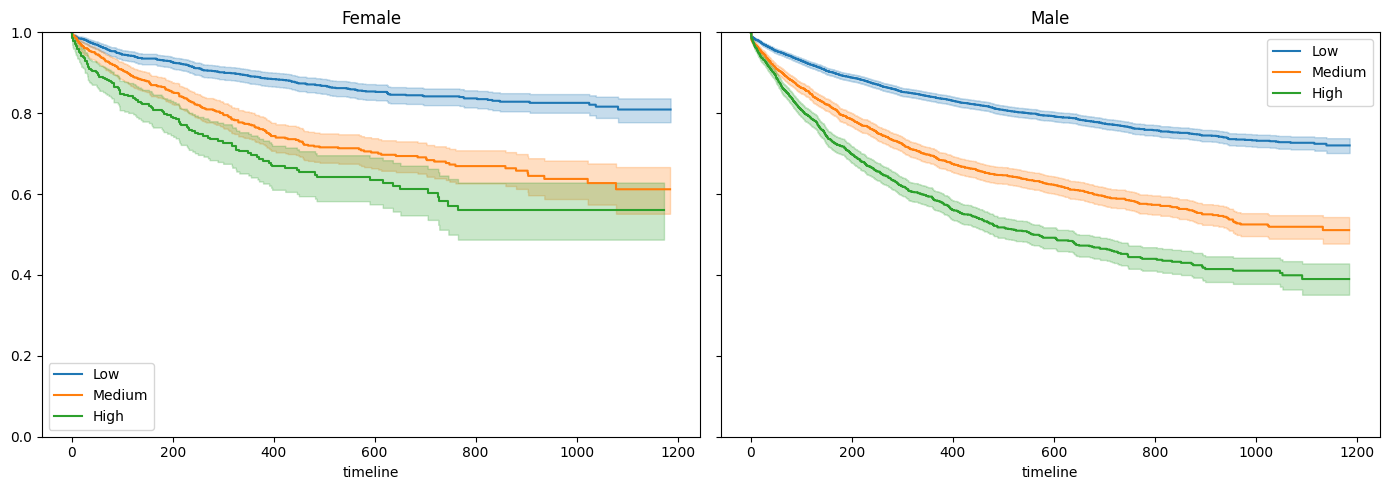

In [72]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
kmf = KaplanMeierFitter()
for ax, subset, title in [(ax1, female_data, 'Female'), (ax2, male_data, 'Male')]:
    for label in ['Low','Medium','High']:
        s = subset[subset['score_text']==label]
        if len(s)>0:
            kmf.fit(s['duration'], event_observed=s['event'], label=label)
            kmf.plot_survival_function(ax=ax, ci_show=True)
    ax.set_title(title)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

As these plots show, the Compas score treats a High risk women the same as a Medium risk man.

## Notes on Python vs R Implementation

**Logistic Regression:** Python's `statsmodels` uses Newton-Raphson optimization by default, while R's `glm` uses Iteratively Reweighted Least Squares (IRLS). Both converge to the same maximum likelihood estimates, so coefficients should be nearly identical. Small differences (e.g., in the 4th or 5th decimal place) are expected and do not affect the conclusions.

**Survival Analysis:** The `lifelines` library in Python does not support the counting process format (`Surv(start, end, event, type="counting")`) in the same way as R's `survival` package. We use the duration (end - start) as the time variable instead. This can lead to slightly different concordance values compared to the R output, but the direction and significance of the findings remain consistent.

**Truth Tables:** The original R notebook imports a custom `truth_tables.py` module from ProPublica. Since that module is not available as a standalone package, the logic was reimplemented directly in pandas. The approach is the same: deduplicate persons, compute 2-year recidivism outcomes, and compare against COMPAS score predictions.

**Factor Reference Levels:** R uses `relevel()` to set reference categories in factor variables. The Python equivalent is `C(variable, Treatment(reference="..."))` in statsmodels formulas. All reference levels match the R script (Caucasian for race, Male for gender, 25-45 for age).